Analysing Ecommerce Sales drop

Company Scenario (Flipkart/Amazon)
We are seeing a drop in revenue find the reason and suggest the actions

In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#reading the data
customers=pd.read_csv('customers.csv')
orders=pd.read_csv('orders.csv')
products=pd.read_csv('products.csv')

In [ ]:
#Merging the datasets
df=pd.merge(customers,orders,on='customer_id',how='inner')
df=pd.merge(df,products,on='product_id',how='inner')
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
#converting object date columns into date-time format
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
#create revenue column
#formula: revenue=price*quantity
df['revenue']=df['price']*df['quantity']
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


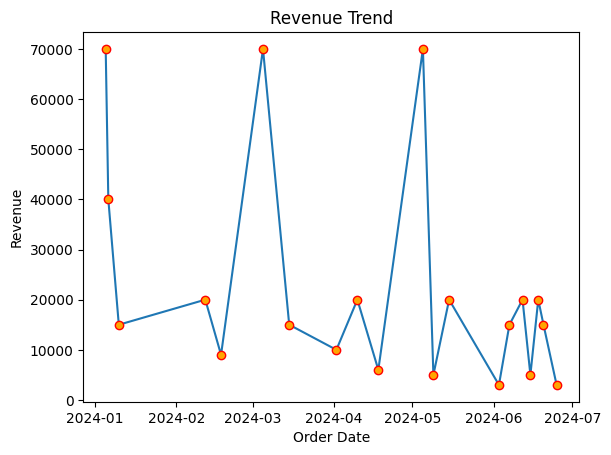

In [ ]:
#Revenue Trend by Order Date
revenue=df.groupby('order_date')['revenue'].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['order_date'],revenue['revenue'],marker='o',mfc='orange',mec='red')
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

The revenue is very less in the last 2 months (Mid May, June, July)

In [ ]:
df["city"].unique()

array(['Hyderabad', 'Bangalore', 'Chennai'], dtype=object)

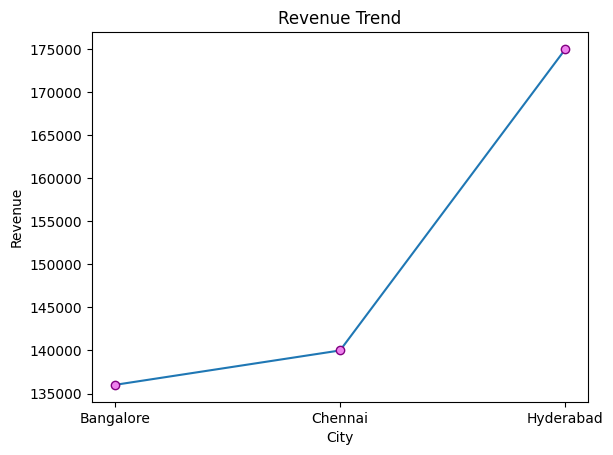

In [ ]:
#Revenue Trend by City
revenue=df.groupby('city')['revenue'].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['city'],revenue['revenue'],marker='o',mfc='violet',mec='purple')
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

Revenue is dropping in Bangalore

In [ ]:
df["category"].unique()

array(['Electronics', 'Fashion'], dtype=object)

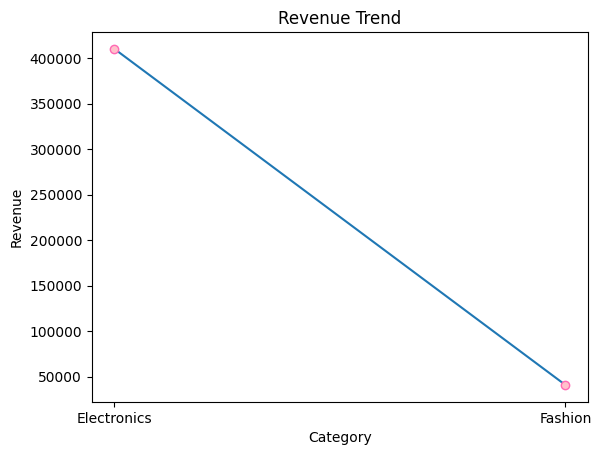

In [ ]:
#Revenue Trend by Category
revenue=df.groupby('category')['revenue'].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['category'],revenue['revenue'],marker='o',mfc='pink',mec='hotpink')
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

  Sales are getting dropped in Fashion Category

In [ ]:
#count customers based on order_id(count of orders per customer)
df.groupby('customer_id')['order_id'].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


Most of the customers are ordering less

In [ ]:
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


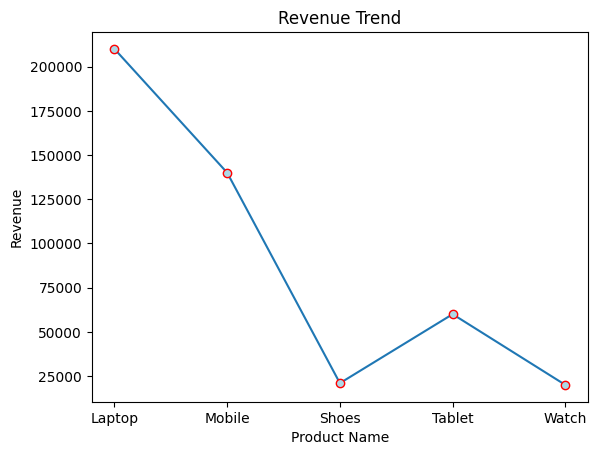

In [ ]:
#Revenue Trend by product_name
revenue=df.groupby('product_name')['revenue'].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['product_name'],revenue['revenue'],marker='o',mfc='lightblue',mec='red')
plt.xlabel("Product Name")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

Revenue is very less for Shoes and Watch

#Insights:
1.   Revenue got dropped in last 2 months (June, July)
2.   Bangalore contributed more in revenue drop
3.   Fashion Category recorded less revenue
4.   Repeated customers ordered less
5.   Shoe and Watch sales declined significantly

#Recommendations:
1.   Proper marketing should  be done in Bangalore
2.   Provide discounts for Shoe and Watch
3.   Coupons, Discounts, Loyalty programs

